Epoch 1/25


/Users/artyomk/dev/projects/market-mind/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6396
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6344
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6341
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6335
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6334
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6324
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6325
Epoch 8/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6323
Epoch 9/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6321
Epoch 10/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6310
Epoch 11/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6316
Epoch 12/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6312
Epoch 13/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6309
Epoch 14/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6311
Epoch 15/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6313
Epoch 16/25
21/21 ━━━━━━━━━━━━

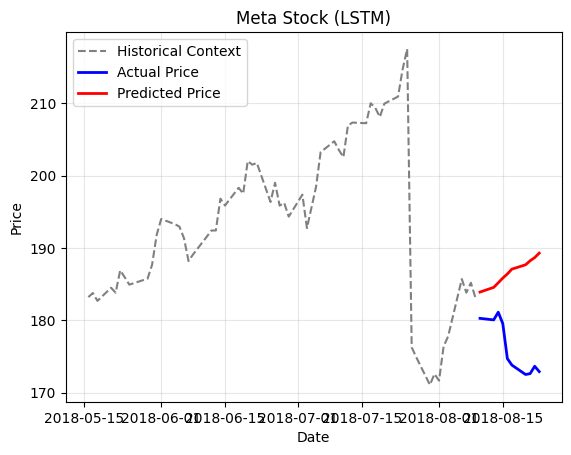

------------------------------
RMSE: 11.7029
NRMSE (Normalized by Range): 1.3592 (135.92%)
NRMSE (Normalized by Mean):  0.0665 (6.65%)
------------------------------
Directional Accuracy: 33.33%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

# All inputs needed for model: date, close price pairs of stock data

# ==========================================
# 1. DATA LOADING & FEATURE ENGINEERING
# ==========================================

title = "Google Stock (LSTM)"
data = pd.read_csv("data/GoogleStock.csv")

data['date'] = pd.to_datetime(data['date'])
data['month_sin'] = np.sin(2 * np.pi * data['date'].dt.month / 12)
data['month_cos'] = np.cos(2 * np.pi * data['date'].dt.month / 12)
data['day_sin'] = np.sin(2 * np.pi * data['date'].dt.dayofweek / 7)
data['day_cos'] = np.cos(2 * np.pi * data['date'].dt.dayofweek / 7)

data['vol_pct_change'] = data['volume'].pct_change()
# Using % change (Returns) to make data stationary (prevents trend-following overfitting)
data['return'] = data['close'].pct_change()
# IMPROVEMENT: Add a 5-day Moving Average of returns to give the model "momentum" context
data['return_mavg'] = data['return'].rolling(window=5).mean()

# Drop rows with NaN values created by pct_change and rolling mean
data = data.dropna().reset_index(drop=True)

feature_cols = ['return', 'return_mavg', 'vol_pct_change', 'month_sin', 'month_cos', 'day_sin', 'day_cos']
dataset = data[feature_cols].values

window_size = 60

# ==========================================
# 2. DATA SPLITTING & SCALING
# ==========================================
training_data_len = int(np.ceil(len(dataset)) * 0.7)

# Scaler is fitted ONLY on training data to avoid data leakage from the future
scaler = StandardScaler()
scaler.fit(dataset[:training_data_len])

scaled_train = scaler.transform(dataset[:training_data_len])
# For testing, we need the 60 days prior to the test start for the first window
scaled_test_source = scaler.transform(dataset[training_data_len - window_size:])

# ==========================================
# 3. MULTI-OUTPUT DATA PREPARATION
# ==========================================
X_train, y_train = [], []
prediction_days = 10  # We want to predict 10 days at once

# We stop earlier (len - prediction_days) to ensure we have a full 10-day 'answer'
for i in range(window_size, len(scaled_train) - prediction_days):
    X_train.append(scaled_train[i-window_size:i, :]) 
    # Grab the next 10 days of the 'return' column (index 0)
    y_train.append(scaled_train[i : i + prediction_days, 0]) 

X_train, y_train = np.array(X_train), np.array(y_train)

# ==========================================
# 4. MODEL ARCHITECTURE & REGULARIZATION
# ==========================================
model = keras.models.Sequential([
    keras.layers.LSTM(32, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.Dropout(0.5),
    keras.layers.LSTM(32, return_sequences=False),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(10) 
])

# IMPROVEMENT: Early Stopping halts training if the model stops improving
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

model.compile(optimizer="adam", loss="mae")
model.fit(X_train, y_train, epochs=25, batch_size=64, callbacks=[early_stop], verbose=1)

# ==========================================
# 5. DIRECT 10-DAY PREDICTION (NO DRIFT LOOP)
# ==========================================
# Grab the very last 60 days of the training/source data to predict the start of the test set
last_x_days = scaled_test_source[:window_size].reshape((1, window_size, len(feature_cols)))

# This returns a single array of 10 predicted returns
predicted_returns_scaled = model.predict(last_x_days)[0] 

# ==========================================
# 6. PRICE RECONSTRUCTION & VISUALIZATION
# ==========================================
# (Same logic as before, just using the 'predicted_returns_scaled' we just got)
dummy_scaler = np.zeros((prediction_days, len(feature_cols)))
dummy_scaler[:, 0] = predicted_returns_scaled
predictions_raw_returns = scaler.inverse_transform(dummy_scaler)[:, 0]

# Reconstruct Prices
last_actual_price = data['close'].iloc[training_data_len - 1]
reconstructed_prices = []
for ret in predictions_raw_returns:
    next_price = last_actual_price * (1 + ret)
    reconstructed_prices.append(next_price)
    last_actual_price = next_price

comparison_period = 10
# Dataframe for the 10-day window
test_df_subset = data[training_data_len : training_data_len + comparison_period].copy()
test_df_subset['Predictions'] = reconstructed_prices

# --- THE FIX: SPLITTING INTO 3 LINES ---


# 1. Historical Context (The trend leading up to the test)
# We plot up to training_data_len to show the "past"
plt.plot(data['date'].iloc[training_data_len-window_size : training_data_len], 
         data['close'].iloc[training_data_len-window_size : training_data_len], 
         label="Historical Context", color='gray', linestyle='--')

# 2. Actual Price (The ground truth during the 10-day window)
plt.plot(test_df_subset['date'], test_df_subset['close'], 
         label="Actual Price", color='blue', linewidth=2)

# 3. Predicted Price (The model's forecast)
plt.plot(test_df_subset['date'], test_df_subset['Predictions'], 
         label="Predicted Price", color='red', linewidth=2)

plt.title(title)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# ==========================================
# 7. DIRECTIONAL ACCURACY CALCULATION
# ==========================================
rmse = np.sqrt(np.mean((test_df_subset['close'] - test_df_subset['Predictions']) ** 2))

# 2. Calculate NRMSE normalized by the Range (Max Price - Min Price)
# This shows the error relative to how much the stock actually moved
price_range = test_df_subset['close'].max() - test_df_subset['close'].min()
nrmse_range = rmse / price_range if price_range != 0 else 0

# 3. Calculate NRMSE normalized by the Mean (Average Price)
# This shows the error as a rough percentage of the stock's total value
price_mean = test_df_subset['close'].mean()
nrmse_mean = rmse / price_mean if price_mean != 0 else 0

print("-" * 30)
print(f"RMSE: {rmse:.4f}")
print(f"NRMSE (Normalized by Range): {nrmse_range:.4f} ({(nrmse_range*100):.2f}%)")
print(f"NRMSE (Normalized by Mean):  {nrmse_mean:.4f} ({(nrmse_mean*100):.2f}%)")
print("-" * 30)

# We compare the 'return' (sign of price movement)
# Actual signs: Was the actual price higher than previous day?
actual_returns = test_df_subset['close'].pct_change().dropna()
# Predicted signs: Was the predicted price higher than previous day?
predicted_returns = test_df_subset['Predictions'].pct_change().dropna()

# Check where the signs match (both up or both down)
# np.sign returns 1 for positive, -1 for negative, 0 for no change
correct_directions = np.sign(actual_returns.values) == np.sign(predicted_returns.values)

directional_accuracy = np.mean(correct_directions) * 100

print(f"Directional Accuracy: {directional_accuracy:.2f}%")


NameError: name 'data' is not defined